In [1]:
#Step 1 Generates a dataset of shape images in COCO format
import subprocess
import os
import shutil

# Define dataset path
dataset_path = "./shapes_dataset"

# Paths for images and annotations
images_dir = os.path.join(dataset_path, "images")
annotations_dir = os.path.join(dataset_path, "annotations")

# Clear the directories before generating new files
if os.path.exists(images_dir):
    shutil.rmtree(images_dir)
    print(f"✅ Cleared old images from: {images_dir}")
else:
    print(f"⚠️ No existing images directory found at: {images_dir}")

if os.path.exists(annotations_dir):
    shutil.rmtree(annotations_dir)
    print(f"✅ Cleared old annotations from: {annotations_dir}")
else:
    print(f"⚠️ No existing annotations directory found at: {annotations_dir}")

# Recreate the directories
os.makedirs(images_dir)
os.makedirs(annotations_dir)
print(f"✅ Created new directories for images and annotations at: {dataset_path}")

# Set dynamic parameters
num_images = 5  # Change this dynamically if needed
image_width = 128  # Change this dynamically if needed
image_height = 128  # Change this dynamically if needed

# Run the dataset generation script inside Jupyter
command = [
    "python", "shapes/run.py",
    "--save_dir", dataset_path,
    "--num_images", str(num_images),
    "--image_size", str(image_width), str(image_height),  # ✅ Explicitly setting image size dynamically
    "--task_type", "segmentation"
]

# Execute the command
result = subprocess.run(command, capture_output=True, text=True)
print(result.stdout)  # Print output for debugging

# Check if dataset is created
coco_annotations_file = os.path.join(annotations_dir, "coco_annotations.json")

if not os.path.exists(coco_annotations_file):
    print("❌ ERROR: Dataset not generated correctly! Check run.py.")
else:
    print(f"✅ Shapes dataset successfully generated with {num_images} images of size {image_width}x{image_height}!")
    print(f"Images are saved in: {images_dir}")
    print(f"Annotations are saved in: {annotations_dir}")
    print(f"COCO annotations file: {coco_annotations_file}")

✅ Cleared old images from: ./shapes_dataset/images
✅ Cleared old annotations from: ./shapes_dataset/annotations
✅ Created new directories for images and annotations at: ./shapes_dataset
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
Before saving - Image dimensions: 128x128 (width x height)
After saving - Image dimensions: 128x128 (width x height)
Figure(640x480)
✅ Dataset and COCO annotations saved to ./shapes_dataset

✅ Shapes dataset successfully generated with 5 images of size 128x128!
Images are saved in:

In [2]:
#Step 2: Load and Verify COCO Annotations
import json

# Define the correct path for the COCO annotations file
OUTPUT_ANNOTATION_FILE = "./shapes_dataset/annotations/coco_annotations.json"

# Verify COCO Annotations
try:
    with open(OUTPUT_ANNOTATION_FILE, "r") as f:
        coco_data = json.load(f)
        # Debugging: Loop over annotations and extract bounding boxes
    for ann in coco_data["annotations"]:
        x, y, w, h = map(int, ann["bbox"])  # Extract coordinates and size
        print(f"🖼 Object | BBox: ({x}, {y}, {w}, {h}) | Size: ({w}x{h})")
        #print(f"🖼 Object | BBox: ({x}, {y}, {x+w}, {y+h}) | Size: ({w}x{h})")


    # Show structure
    print("✅ COCO Annotations Loaded Successfully!")
    print(json.dumps(coco_data, indent=4)[:1000])  # Print first 1000 characters

except FileNotFoundError:
    print(f"❌ ERROR: The file {OUTPUT_ANNOTATION_FILE} was not found. Make sure it was generated correctly!")

🖼 Object | BBox: (42, -2, 34, 34) | Size: (34x34)
🖼 Object | BBox: (43, 109, 19, 19) | Size: (19x19)
🖼 Object | BBox: (3, 76, 24, 24) | Size: (24x24)
🖼 Object | BBox: (19, 45, 34, 34) | Size: (34x34)
🖼 Object | BBox: (93, 100, 22, 22) | Size: (22x22)
🖼 Object | BBox: (103, 17, 44, 44) | Size: (44x44)
🖼 Object | BBox: (16, 44, 44, 44) | Size: (44x44)
🖼 Object | BBox: (49, 66, 18, 18) | Size: (18x18)
🖼 Object | BBox: (51, 74, 15, 15) | Size: (15x15)
🖼 Object | BBox: (10, 19, 24, 24) | Size: (24x24)
✅ COCO Annotations Loaded Successfully!
{
    "images": [
        {
            "id": 0,
            "width": 128,
            "height": 128,
            "file_name": "shapes_0.png"
        },
        {
            "id": 1,
            "width": 128,
            "height": 128,
            "file_name": "shapes_1.png"
        },
        {
            "id": 2,
            "width": 128,
            "height": 128,
            "file_name": "shapes_2.png"
        },
        {
            "id": 3,
    

✅ Checkpoint already exists at: /Users/ma/Documents/samThesis/segment-anything/weights/sam_vit_h_4b8939.pth
✅ Loaded COCO annotations from ./shapes_dataset/annotations/coco_annotations.json
🔹 Total Images: 5 | Total Annotations: 10
📌 Loaded shapes_0.png | Image Size: (128, 128) (Height, Width) | original img w: 128 | original img h: 128


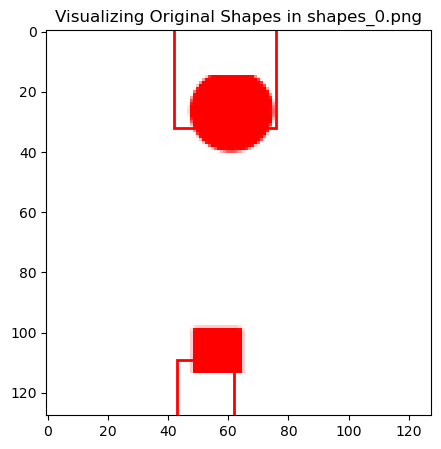

🛠 Input Box for SAM: [42 -2 34 34]
✅ 3 masks detected.
🛠 Input Box for SAM: [ 43 109  19  19]
✅ 3 masks detected.


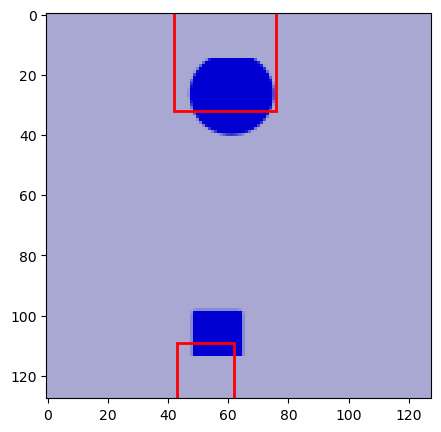

📌 Loaded shapes_1.png | Image Size: (128, 128) (Height, Width) | original img w: 128 | original img h: 128


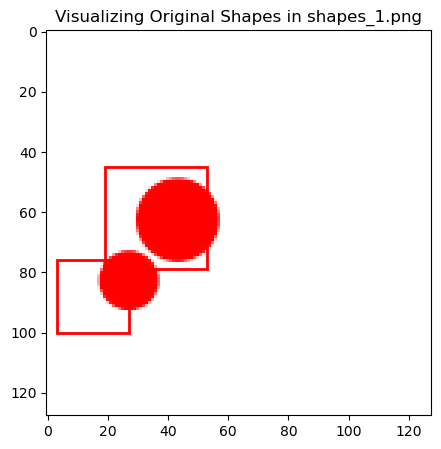

🛠 Input Box for SAM: [ 3 76 24 24]
✅ 3 masks detected.
🛠 Input Box for SAM: [19 45 34 34]
✅ 3 masks detected.


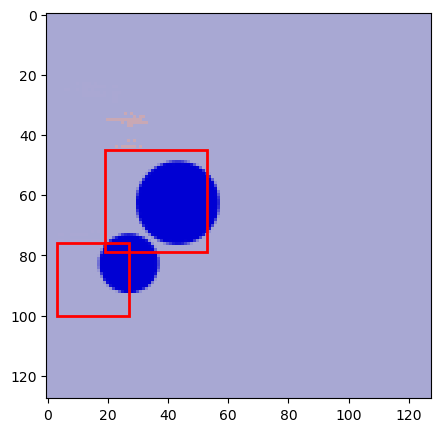

📌 Loaded shapes_2.png | Image Size: (128, 128) (Height, Width) | original img w: 128 | original img h: 128


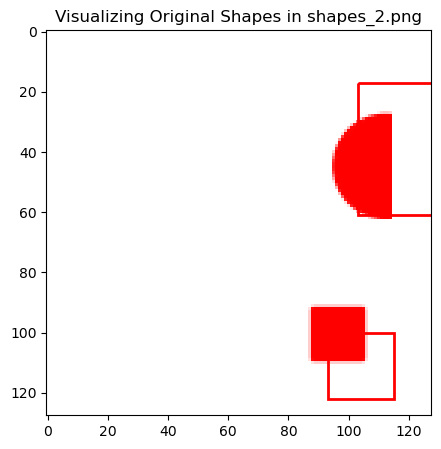

🛠 Input Box for SAM: [ 93 100  22  22]
✅ 3 masks detected.
🛠 Input Box for SAM: [103  17  44  44]
✅ 3 masks detected.


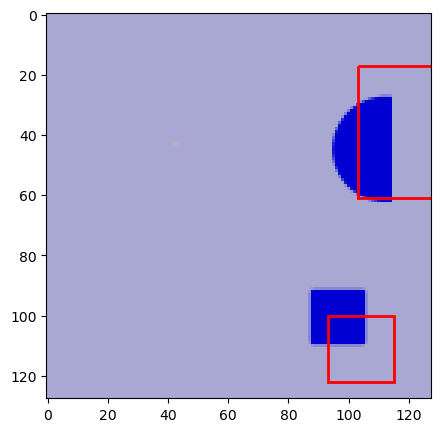

📌 Loaded shapes_3.png | Image Size: (128, 128) (Height, Width) | original img w: 128 | original img h: 128


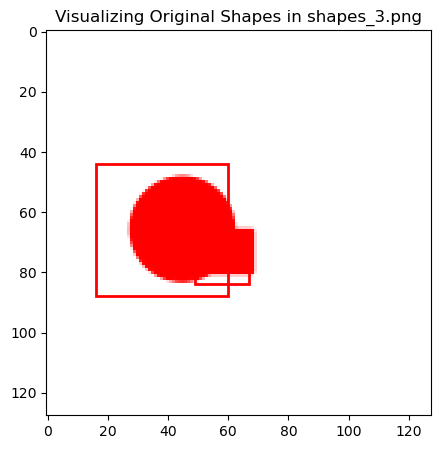

🛠 Input Box for SAM: [16 44 44 44]
✅ 3 masks detected.
🛠 Input Box for SAM: [49 66 18 18]
✅ 3 masks detected.


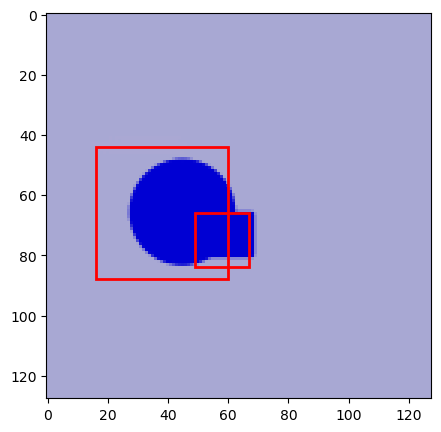

📌 Loaded shapes_4.png | Image Size: (128, 128) (Height, Width) | original img w: 128 | original img h: 128


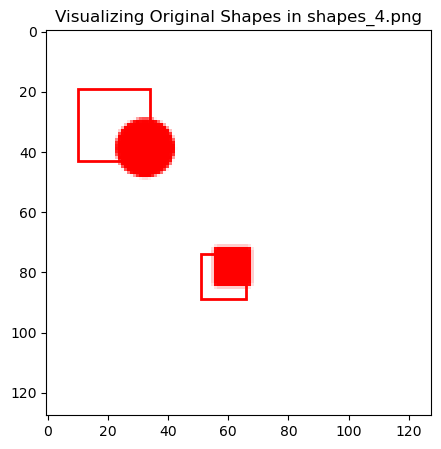

🛠 Input Box for SAM: [51 74 15 15]
✅ 3 masks detected.
🛠 Input Box for SAM: [10 19 24 24]
✅ 3 masks detected.


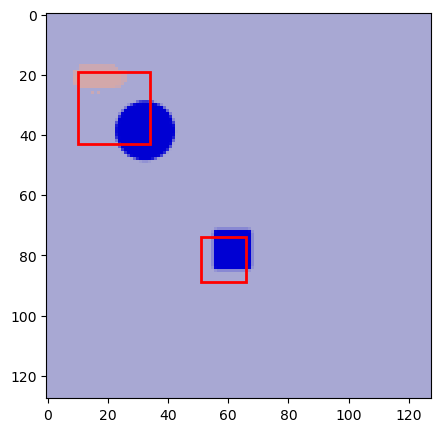


✅ SAM Masks Generated and Saved in COCO Format!
🔹 Total Images Processed: 5 | Masks Generated: 9 | No Masks: 0

🔹 Full Summary of Results:

📌 shapes_0.png - Before and After Processing:
   🔹 Before Processing - Size: (128, 128)
   🔹 After Processing - Size: (128, 128)
   🔹 Masks Detected: 6
   🔹 Masks Generated: 0
   🔹 No Masks Found: 0

📌 shapes_1.png - Before and After Processing:
   🔹 Before Processing - Size: (128, 128)
   🔹 After Processing - Size: (128, 128)
   🔹 Masks Detected: 6
   🔹 Masks Generated: 2
   🔹 No Masks Found: 0

📌 shapes_2.png - Before and After Processing:
   🔹 Before Processing - Size: (128, 128)
   🔹 After Processing - Size: (128, 128)
   🔹 Masks Detected: 6
   🔹 Masks Generated: 2
   🔹 No Masks Found: 0

📌 shapes_3.png - Before and After Processing:
   🔹 Before Processing - Size: (128, 128)
   🔹 After Processing - Size: (128, 128)
   🔹 Masks Detected: 6
   🔹 Masks Generated: 2
   🔹 No Masks Found: 0

📌 shapes_4.png - Before and After Processing:
   🔹 Before P

In [3]:
# Step 3: Load SAM Model & Process COCO Annotations with Visualization
import os
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# ============================
# 🔹 Load SAM Model with Debugging
# ============================

CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
WEIGHTS_DIR = "/Users/ma/Documents/samThesis/segment-anything/weights"
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, "sam_vit_h_4b8939.pth")

# Create directory if needed
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Download checkpoint if not exists
if not os.path.isfile(CHECKPOINT_PATH):
    os.system(f"curl -o {CHECKPOINT_PATH} {CHECKPOINT_URL}")
    print(f"✅ Downloaded SAM checkpoint to: {CHECKPOINT_PATH}")
else:
    print(f"✅ Checkpoint already exists at: {CHECKPOINT_PATH}")

# Load SAM model
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
predictor = SamPredictor(sam)

# ============================
# 🔹 Load COCO Annotations with Debugging
# ============================

DATASET_PATH = "./shapes_dataset"
ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations.json")
OUTPUT_ANNOTATION_FILE = os.path.join(DATASET_PATH, "annotations/coco_annotations_with_masks.json")

# Check if annotation file exists
if not os.path.exists(ANNOTATION_FILE):
    print(f"❌ ERROR: COCO annotation file not found: {ANNOTATION_FILE}")
    raise FileNotFoundError(f"COCO annotation file {ANNOTATION_FILE} does not exist!")

# Load COCO JSON
with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO annotations from {ANNOTATION_FILE}")
print(f"🔹 Total Images: {len(coco_data['images'])} | Total Annotations: {len(coco_data['annotations'])}")

# Debug: Check if images exist
if len(coco_data["images"]) == 0:
    print("⚠️ WARNING: No images found in COCO annotations! Check dataset generation.")
    raise ValueError("COCO dataset has no images!")

# Debug: Check if annotations exist
if len(coco_data["annotations"]) == 0:
    print("⚠️ WARNING: No annotations found in COCO annotations! Expected bounding boxes.")
    raise ValueError("COCO dataset has no annotations!")

# ============================
# 🔹 Run SAM on Each Image & Generate Masks (with Normalization & Visualization)
# ============================

new_annotations = []
masks_generated = 0
no_masks_found = 0

# For final summary of results
image_summary = []

for img_info in coco_data["images"]:
    img_path = os.path.join(DATASET_PATH, "images", img_info["file_name"])

    # Check if image exists
    if not os.path.exists(img_path):
        print(f"⚠️ Skipping: {img_info['file_name']} (File Not Found)")
        continue

    # Load image
    image = cv2.imread(img_path)
    
    # Debugging: Print image size after loading
    original_img_width, original_img_height = image.shape[0], image.shape[1]
    print(f"📌 Loaded {img_info['file_name']} | Image Size: {image.shape[:2]} (Height, Width) | original img w: {original_img_width} | original img h: {original_img_height}")

    # ============================
    # 🔹 Visualization of Original Shapes (Before SAM Processing)
    # ============================
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image)

    # Visualize the bounding boxes for debugging
    img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_info["id"]]
    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = map(int, bbox)

        # Draw bounding box around the original shapes
        rect = plt.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

    # Display the image with bounding boxes
    plt.title(f"Visualizing Original Shapes in {img_info['file_name']}")
    plt.show()

    # Convert image to RGB for SAM model
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image)

    # Initialize variables to track masks and image dimensions
    processed_img_width, processed_img_height = image.shape[1], image.shape[0]
    masks_detected_per_image = 0
    masks_generated_per_image = 0

    # Save before processing details for final summary
    image_summary.append({
        "image_name": img_info['file_name'],
        "before_processing_dimensions": (original_img_width, original_img_height),
        "bounding_boxes": [],
        "masks_detected": 0,
        "masks_generated": 0,
        "no_masks_found": 0
    })

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image)

    for ann in img_annotations:
        bbox = ann["bbox"]
        x, y, w, h = map(int, bbox)

        # Adjusted Input Box for SAM (using absolute coordinates)
        input_box = np.array([x, y, w, h])

        # Debugging: Print bounding box details for SAM
        print(f"🛠 Input Box for SAM: {input_box}")

        # Run SAM for segmentation mask generation
        sam_masks, _, _ = predictor.predict(box=input_box)

        # Debugging: Check if SAM generated masks
        if len(sam_masks) == 0:
            print(f"⚠️ No masks found for {img_info['file_name']}! Skipping annotation.")
            no_masks_found += 1
            continue
        else:
            print(f"✅ {len(sam_masks)} masks detected.")
            masks_detected_per_image += len(sam_masks)

        # ✅ Draw Bounding Box
        rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        ax.add_patch(rect)

        # Normalize & Convert Mask to COCO Segmentation Format
        for mask in sam_masks:
            mask_indices = np.argwhere(mask)  # Get mask pixel positions
            mask_indices = mask_indices.astype(np.float32)  # Ensure float precision

            # Normalize the mask positions relative to the image size
            mask_indices[:, 0] /= original_img_height  # Normalize Y
            mask_indices[:, 1] /= original_img_width   # Normalize X

            # Scale back to pixel values for COCO format
            mask_indices[:, 0] *= original_img_height
            mask_indices[:, 1] *= original_img_width

            segmentation = mask_indices.flatten().tolist()

            # Convert mask to 0/1 binary format for better display
            mask = np.uint8(mask)  # Convert to uint8 (0 or 255 for black and white mask)
            
            # Display the mask with better contrast and transparency
            ax.imshow(mask, alpha=0.5, cmap="jet")  # Use 'jet' colormap or try 'hsv' for more contrast
            ax.imshow(image, alpha=0.5)  # Show original image with some transparency to overlay the mask

            # Save updated annotation with segmentation mask
            if segmentation:
                new_annotations.append({
                    "id": len(new_annotations) + 1,
                    "image_id": img_info["id"],
                    "category_id": ann["category_id"],
                    "segmentation": [segmentation],  # List of coordinates
                    "area": int(np.sum(mask)),  # Mask area
                    "bbox": ann["bbox"],  # Keep original bbox
                    "iscrowd": 0
                })
                masks_generated += 1
                masks_generated_per_image += 1

    plt.show()  # Show visualization per image

    # Save processed image details for final summary
    processed_img_width, processed_img_height = image.shape[1], image.shape[0]
    
    # Check if image dimensions changed (resized)
    if (processed_img_width, processed_img_height) != (original_img_width, original_img_height):
        print(f"⚠️ Image {img_info['file_name']} was resized during processing!")

    image_summary[-1]["after_processing_dimensions"] = (processed_img_width, processed_img_height)
    image_summary[-1]["masks_detected"] = masks_detected_per_image
    image_summary[-1]["masks_generated"] = masks_generated_per_image
    image_summary[-1]["no_masks_found"] = no_masks_found

# ============================
# 🔹 Save Updated COCO Annotations
# ============================

# Update annotations in COCO JSON
coco_data["annotations"] = new_annotations

# Save updated COCO JSON
with open(OUTPUT_ANNOTATION_FILE, "w") as f:
    json.dump(coco_data, f, indent=4)

# Debugging Summary After Processing All Images
print("\n✅ SAM Masks Generated and Saved in COCO Format!")
print(f"🔹 Total Images Processed: {len(coco_data['images'])} | Masks Generated: {masks_generated} | No Masks: {no_masks_found}")

# Final Full Summary of Results:
print("\n🔹 Full Summary of Results:")
for img_info in image_summary:
    print(f"\n📌 {img_info['image_name']} - Before and After Processing:")
    print(f"   🔹 Before Processing - Size: {img_info['before_processing_dimensions']}")
    print(f"   🔹 After Processing - Size: {img_info['after_processing_dimensions']}")
    print(f"   🔹 Masks Detected: {img_info['masks_detected']}")
    print(f"   🔹 Masks Generated: {img_info['masks_generated']}")
    print(f"   🔹 No Masks Found: {img_info['no_masks_found']}")

# Final validation check
if len(new_annotations) == 0:
    print("❌ ERROR: No segmentation data generated! Check SAM mask outputs.")

In [4]:
# Step 4: Verify Updated COCO Annotations
# Load updated COCO annotations
with open(OUTPUT_ANNOTATION_FILE, "r") as f:
    updated_coco_data = json.load(f)
# Debugging: Loop over annotations and extract bounding boxes
for ann in coco_data["annotations"]:
    x, y, w, h = map(int, ann["bbox"])  # Extract coordinates and size
    print(f"🖼 Object | BBox: ({x}, {y}, {x+w}, {y+h}) | Size: ({w}x{h})")

# Check if segmentation is now included
sample_ann = next((ann for ann in updated_coco_data["annotations"] if "segmentation" in ann), None)

if sample_ann:
    print("✅ Segmentation Data Found in COCO Format!")
    print(json.dumps(sample_ann, indent=4))
else:
    print("❌ ERROR: No segmentation data found. Ensure SAM generated masks correctly!")


🖼 Object | BBox: (3, 76, 27, 100) | Size: (24x24)
🖼 Object | BBox: (19, 45, 53, 79) | Size: (34x34)
🖼 Object | BBox: (103, 17, 147, 61) | Size: (44x44)
🖼 Object | BBox: (103, 17, 147, 61) | Size: (44x44)
🖼 Object | BBox: (16, 44, 60, 88) | Size: (44x44)
🖼 Object | BBox: (16, 44, 60, 88) | Size: (44x44)
🖼 Object | BBox: (10, 19, 34, 43) | Size: (24x24)
🖼 Object | BBox: (10, 19, 34, 43) | Size: (24x24)
🖼 Object | BBox: (10, 19, 34, 43) | Size: (24x24)
✅ Segmentation Data Found in COCO Format!
{
    "id": 1,
    "image_id": 1,
    "category_id": 1,
    "segmentation": [
        [
            23.0,
            10.0,
            23.0,
            12.0,
            23.0,
            13.0,
            23.0,
            14.0,
            23.0,
            16.0,
            24.0,
            12.0,
            24.0,
            13.0,
            24.0,
            14.0,
            24.0,
            15.0,
            24.0,
            16.0,
            24.0,
            17.0,
            24.0,
  

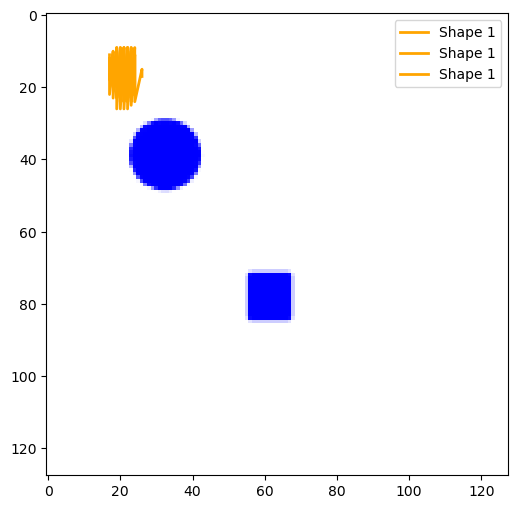

In [5]:
# Step 5: Visualize the Segmentation Masks
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# Define the directory where your images are stored
image_dir = "./shapes_dataset/images"  # Adjust this path as necessary

# Define custom colors for each category
category_colors = {
    1: 'orange',   # Category 1 (e.g., "circle")
    2: 'pink',  # Category 2 (e.g., "rectangle")
}

# Pick a random image
image_id = np.random.choice(len(updated_coco_data["images"]))
image_info = updated_coco_data["images"][image_id]
image_path = os.path.join(image_dir, image_info["file_name"])

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image)

# Iterate through annotations and plot the segmentation masks with appropriate colors
for ann in updated_coco_data["annotations"]:
    if ann["image_id"] == image_info["id"]:
        for seg in ann["segmentation"]:
            poly = np.array(seg).reshape(-1, 2)
            # Get the color for the category, default to 'gray' if not found
            color = category_colors.get(ann['category_id'], 'gray')  
            ax.plot(poly[:, 0], poly[:, 1], linewidth=2, label=f"Shape {ann['category_id']}", color=color)

# Display the legend
ax.legend()

# Show the plot
plt.show()